# SILCC temperatures

In [1]:
import numpy as np
import yt
import pickle
import matplotlib.pyplot as plt
from astropy import units as u, constants  as c

pc = c.pc.cgs.value
kB  = c.k_B.cgs.value
Msun = c.M_sun.cgs.value
G = c.G.cgs.value
Myr = u.Myr.to("s")
mp = c.m_p.cgs.value

In [2]:
ds = yt.load("../sim-data/SILCC_hdf5_plt_cnt_3000")

yt : [INFO     ] 2026-06-26 10:20:56,757 Parameters: current_time              = 946084486762394.1
yt : [INFO     ] 2026-06-26 10:20:56,758 Parameters: domain_dimensions         = [8 8 8]
yt : [INFO     ] 2026-06-26 10:20:56,758 Parameters: domain_left_edge          = [-7.715e+20 -7.715e+20 -7.715e+20]
yt : [INFO     ] 2026-06-26 10:20:56,758 Parameters: domain_right_edge         = [7.715e+20 7.715e+20 7.715e+20]
yt : [INFO     ] 2026-06-26 10:20:56,759 Parameters: cosmological_simulation   = 0


In [3]:
ad = ds.all_data()

In [4]:
Nbinrho = 20
NbinT   = 200
logrho_bnds = np.linspace(-27,-20,Nbinrho)
logT_bnds   = np.linspace(1, 7, NbinT)
H, edx, edy = np.histogram2d(np.log10(ad[("gas","density")]), np.log10(ad[("gas","temperature")]), bins=(logrho_bnds,logT_bnds))
logrho = 0.5*(edx[1:]+edx[:-1])
logT   = 0.5*(edy[1:]+edy[:-1])

[1.38262217e+06 1.04737090e+06 9.77124154e+05 5.23109931e+05
 3.25508860e+04 1.07189132e+04 6.15098579e+03 4.99450512e+03
 4.05546074e+03 7.66341087e+02 2.89942285e+02 1.55222536e+02
 9.54771611e+01 6.29498899e+01 4.44878283e+01 3.37006433e+01
 2.73644000e+01 2.38168555e+01 2.55290807e+01]


/var/folders/lq/sxc6dpqd4l15_k4s7smgt4sc0000gn/T/ipykernel_22557/2551434805.py:2: RuntimeWarning: divide by zero encountered in log10
  ax.imshow(np.log10(H.T), origin="lower", extent=[logrho[0],logrho[-1],logT[0],logT[-1]])


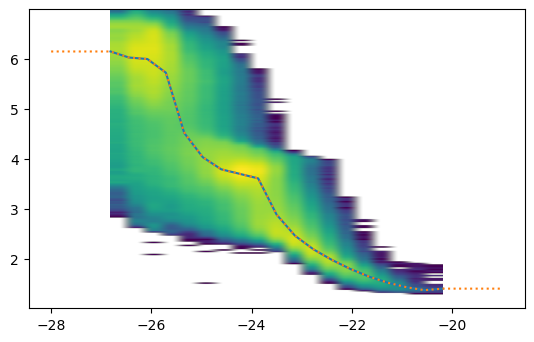

In [5]:
fig, ax = plt.subplots()
ax.imshow(np.log10(H.T), origin="lower", extent=[logrho[0],logrho[-1],logT[0],logT[-1]])

# cumulative sum along y
cdf = np.cumsum(H.T, axis=0)

# normalize to [0,1]
cdf /= cdf[-1, :]

# index where cdf first exceeds 0.5
logTeq = logT[np.argmax(cdf >= 0.5, axis=0)]
Teq = np.power(10,logTeq)
#Teq = np.median(H.T, axis =0)
ax.plot(logrho, logTeq)
print(Teq)
# interpolate
rho_test = np.linspace(-28,-19,300)
Teq_interp = np.interp(rho_test, logrho, logTeq)
ax.plot(rho_test, Teq_interp, ls = ":")

In [6]:
# store equilibrium temperature
data_Teq = {}
data_Teq["logTeq"] = logTeq
data_Teq["logrho"] = logrho
data_Teq["logn"]   = np.power(10.0, logrho) / (1.4 * mp)

with open('../sim-data/SILCC-equilibrium-temperature.pkl', 'wb') as handle:
    pickle.dump(data_Teq, handle, protocol=pickle.HIGHEST_PROTOCOL)
